# 01 Data Overview — Thailand Economic Analysis System

**วัตถุประสงค์:** ตรวจสอบคุณภาพข้อมูลดิบก่อนทำ cleaning

**คำถามที่ต้องตอบได้ก่อนออกจาก notebook นี้:**
1. ข้อมูลแต่ละแหล่งครอบคลุมช่วงเวลาไหน?
2. มี missing values ที่ไหน กี่เปอร์เซนต์?
3. ข้อมูลดูสมเหตุสมผลไหม? มี outlier หรือค่าผิดปกติไหม?
4. มีปัญหาอะไรที่ต้องแก้ใน `02_data_cleaning.ipynb`?

| Layer | Source | Frequency | Series |
|---|---|---|---|
| Market signals | yfinance | Daily | 8 tickers |
| Macro indicators | World Bank + IMF | Annual | 10 indicators |
| High-frequency proxy | FRED | Monthly | 11 series |
| News sentiment | Bangkok Post RSS | Snapshot | 1 file |

In [4]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', '{:.3f}'.format)

RAW_DIR  = Path('../../data/raw')
PROC_DIR = Path('../../data/processed')

In [5]:
def load_market(name):
    df = pd.read_csv(RAW_DIR / f'{name}_market_signals.csv', parse_dates=['date'])
    return df.set_index('date')['close'].rename(name)

def load_macro(filename, col):
    df = pd.read_csv(RAW_DIR / filename)
    df['year']  = pd.to_numeric(df['year'],  errors='coerce')
    df['value'] = pd.to_numeric(df['value'], errors='coerce')
    return df.dropna(subset=['year','value']).set_index('year')['value'].rename(col)

def load_fred(name):
    df = pd.read_csv(RAW_DIR / f'fred_{name}.csv', parse_dates=['date'])
    return df.set_index('date')['value'].rename(name)

MARKET_NAMES = ['SET_index','USD_THB','vix','gold','oil','sp500','us_10yr_treasury','nasdaq']
market = pd.concat([load_market(n) for n in MARKET_NAMES], axis=1).sort_index()

macro = pd.concat([
    load_macro('consumption_pct_gdp_TH.csv',     'consumption'),
    load_macro('lending_rate_TH.csv',             'lending_rate'),
    load_macro('inflation_TH.csv',                'inflation'),
    load_macro('thailand_unemployment_rate.csv',  'unemployment'),
    load_macro('gross_capital_formation_TH.csv',  'business_invest'),
    load_macro('exports_pct_gdp_TH.csv',          'exports_pct_gdp'),
    load_macro('imports_pct_gdp_TH.csv',          'imports_pct_gdp'),
    load_macro('imf_gdp_growth_TH.csv',           'gdp_growth'),
    load_macro('govt_expenditure_pct_gdp_TH.csv', 'govt_expenditure'),
    load_macro('govt_debt_pct_gdp_TH.csv',        'govt_debt'),
], axis=1).sort_index()

FRED_NAMES = ['th_exchange_rate_real','th_us_imports','th_property_prices','th_uncertainty',
              'us_fed_funds_rate','us_cpi_monthly','us_unemployment','us_industrial_prod',
              'global_uncertainty','us_consumer_sentiment','us_govt_spending']
fred = pd.concat([load_fred(n) for n in FRED_NAMES], axis=1).sort_index()

news = pd.read_csv(RAW_DIR / 'news_sentiment.csv')
news['published'] = pd.to_datetime(news['published'], errors='coerce')

print(f'market : {market.shape}  {market.index[0].date()} → {market.index[-1].date()}')
print(f'macro  : {macro.shape}   year {int(macro.index.min())} → {int(macro.index.max())}')
print(f'fred   : {fred.shape}  {fred.index[0].date()} → {fred.index[-1].date()}')
print(f'news   : {news.shape}')

market : (6088, 8)  2003-01-02 → 2026-05-08
macro  : (31, 10)   year 2001 → 2031
fred   : (280, 11)  2003-01-01 → 2026-04-01
news   : (10, 5)


## 1. Data Inventory
สรุปว่าแต่ละแหล่งมีอะไร กี่แถว ช่วงเวลาไหน missing กี่%

In [6]:
rows = []
for col in market.columns:
    s = market[col].dropna()
    rows.append({'source':'yfinance','layer':'Market (daily)','series':col,
                 'rows':len(s),'start':str(s.index.min().date()),'end':str(s.index.max().date()),
                 'freq':'D','missing_%':round(market[col].isna().mean()*100,1)})
for col in macro.columns:
    s = macro[col].dropna()
    rows.append({'source':'WB/IMF','layer':'Macro (annual)','series':col,
                 'rows':len(s),'start':str(int(s.index.min())),'end':str(int(s.index.max())),
                 'freq':'Y','missing_%':round(macro[col].isna().mean()*100,1)})
for col in fred.columns:
    s = fred[col].dropna()
    rows.append({'source':'FRED','layer':'FRED (monthly)','series':col,
                 'rows':len(s),'start':str(s.index.min().date()),'end':str(s.index.max().date()),
                 'freq':'M','missing_%':round(fred[col].isna().mean()*100,1)})
rows.append({'source':'Bangkok Post','layer':'News (snapshot)','series':'news_sentiment',
             'rows':len(news),'start':'current','end':'current','freq':'snapshot','missing_%':0})

inventory = pd.DataFrame(rows)
print(f'Total series: {len(inventory)-1}  |  Total rows across data files: {inventory["rows"].sum():,}')
inventory.style.background_gradient(subset=['missing_%'], cmap='YlOrRd')

Total series: 29  |  Total rows across data files: 49,474


,source,layer,series,rows,start,end,freq,missing_%
0,yfinance,Market (daily),SET_index,5683,2003-01-02,2026-05-08,D,6.700000
1,yfinance,Market (daily),USD_THB,5820,2003-12-01,2026-05-08,D,4.400000
2,yfinance,Market (daily),vix,5875,2003-01-02,2026-05-08,D,3.500000
3,yfinance,Market (daily),gold,5865,2003-01-02,2026-05-08,D,3.700000
4,yfinance,Market (daily),oil,5869,2003-01-02,2026-05-08,D,3.600000
5,yfinance,Market (daily),sp500,5875,2003-01-02,2026-05-08,D,3.500000
6,yfinance,Market (daily),us_10yr_treasury,5869,2003-01-02,2026-05-08,D,3.600000
7,yfinance,Market (daily),nasdaq,5875,2003-01-02,2026-05-08,D,3.500000
8,WB/IMF,Macro (annual),consumption,22,2003,2024,Y,29.000000
9,WB/IMF,Macro (annual),lending_rate,22,2001,2024,Y,29.000000


## 2. Coverage Timeline
แสดงว่าแต่ละ series มีข้อมูลครอบคลุมช่วงไหน — เส้นแดงคือ 2003 (common start)

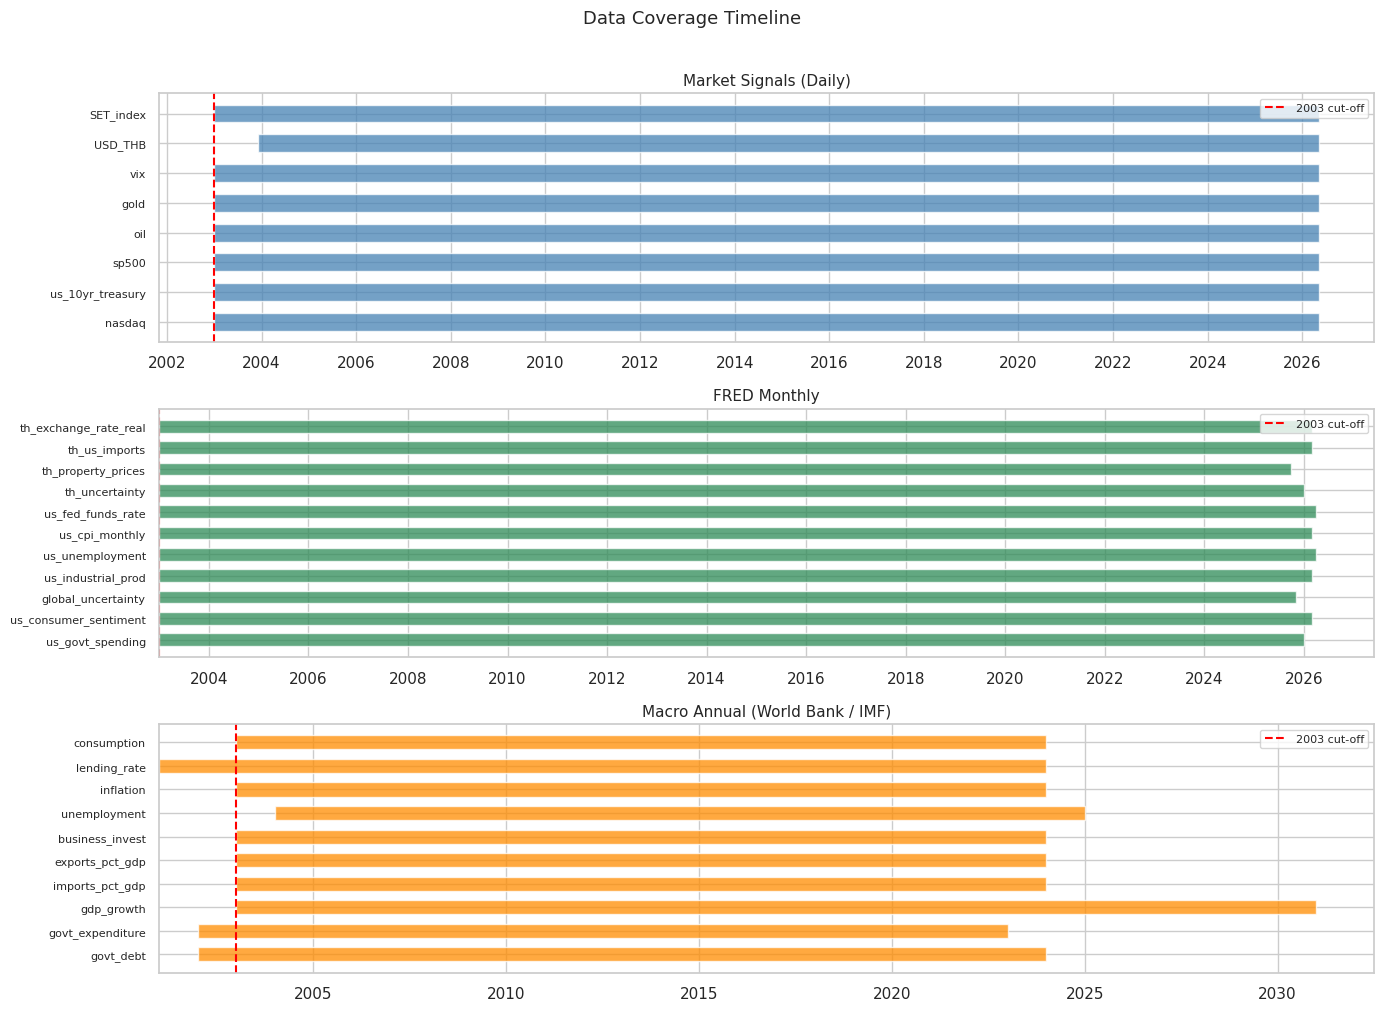

In [7]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# Market
for i, col in enumerate(reversed(MARKET_NAMES)):
    s = market[col].dropna()
    if len(s)==0: continue
    lo = mdates.date2num(s.index.min())
    hi = mdates.date2num(s.index.max())
    axes[0].barh(i, hi-lo, left=lo, height=0.6, color='steelblue', alpha=0.75)
axes[0].set_yticks(range(len(MARKET_NAMES)))
axes[0].set_yticklabels(list(reversed(MARKET_NAMES)), fontsize=8)
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axes[0].xaxis.set_major_locator(mdates.YearLocator(2))
axes[0].axvline(mdates.date2num(pd.Timestamp('2003-01-01')), color='red', ls='--', lw=1.5, label='2003 cut-off')
axes[0].set_title('Market Signals (Daily)', fontsize=11); axes[0].legend(fontsize=8)

# FRED
for i, col in enumerate(reversed(FRED_NAMES)):
    s = fred[col].dropna()
    if len(s)==0: continue
    lo = mdates.date2num(s.index.min())
    hi = mdates.date2num(s.index.max())
    axes[1].barh(i, hi-lo, left=lo, height=0.6, color='seagreen', alpha=0.75)
axes[1].set_yticks(range(len(FRED_NAMES)))
axes[1].set_yticklabels(list(reversed(FRED_NAMES)), fontsize=8)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axes[1].xaxis.set_major_locator(mdates.YearLocator(2))
axes[1].axvline(mdates.date2num(pd.Timestamp('2003-01-01')), color='red', ls='--', lw=1.5, label='2003 cut-off')
axes[1].set_title('FRED Monthly', fontsize=11); axes[1].legend(fontsize=8)

# Macro
macro_cols = list(macro.columns)
for i, col in enumerate(reversed(macro_cols)):
    s = macro[col].dropna()
    if len(s)==0: continue
    axes[2].barh(i, s.index.max()-s.index.min(), left=s.index.min(), height=0.6, color='darkorange', alpha=0.75)
axes[2].set_yticks(range(len(macro_cols)))
axes[2].set_yticklabels(list(reversed(macro_cols)), fontsize=8)
axes[2].axvline(2003, color='red', ls='--', lw=1.5, label='2003 cut-off')
axes[2].set_title('Macro Annual (World Bank / IMF)', fontsize=11); axes[2].legend(fontsize=8)

plt.suptitle('Data Coverage Timeline', fontsize=13, y=1.01)
plt.tight_layout(); plt.show()

## 3. Missing Values
ถ้าเกิน 50% ต้องพิจารณาตัดทิ้ง — ถ้าน้อยกว่า 5% สามารถ impute ได้

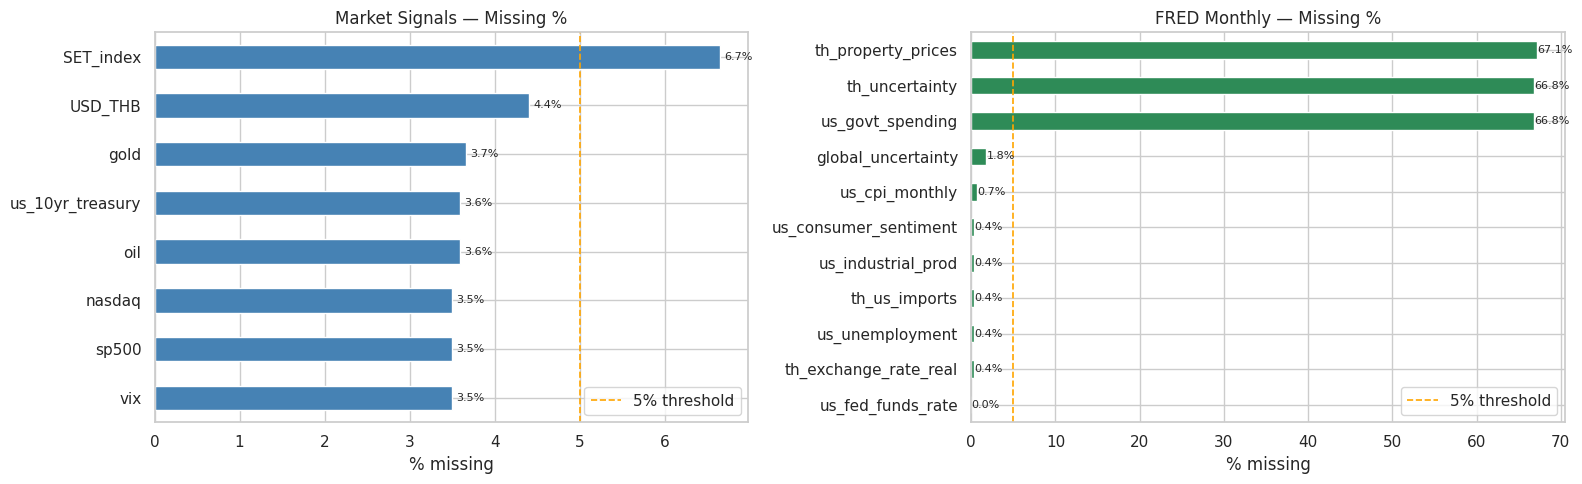

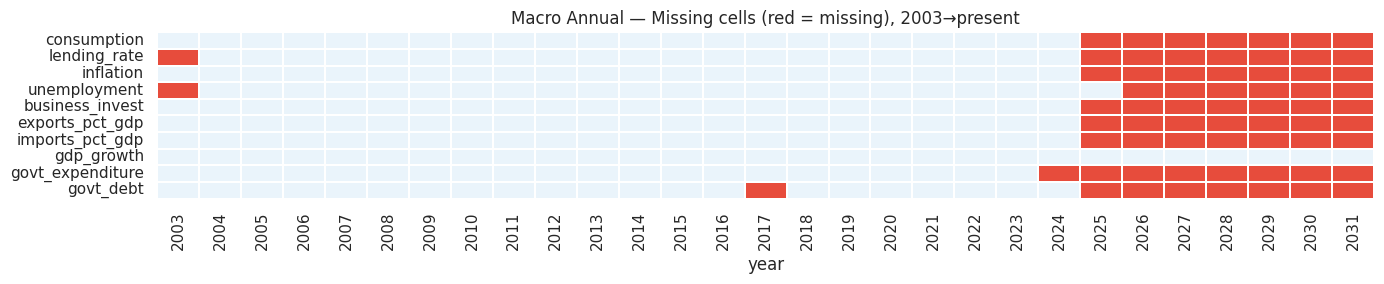

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

miss_m = (market.isna().mean()*100).sort_values()
miss_m.plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].axvline(5, color='orange', ls='--', lw=1.2, label='5% threshold')
axes[0].set_title('Market Signals — Missing %'); axes[0].set_xlabel('% missing'); axes[0].legend()
for b,v in zip(axes[0].patches, miss_m): axes[0].text(v+0.05, b.get_y()+b.get_height()/2, f'{v:.1f}%', va='center', fontsize=8)

miss_f = (fred.isna().mean()*100).sort_values()
miss_f.plot(kind='barh', ax=axes[1], color='seagreen')
axes[1].axvline(5, color='orange', ls='--', lw=1.2, label='5% threshold')
axes[1].set_title('FRED Monthly — Missing %'); axes[1].set_xlabel('% missing'); axes[1].legend()
for b,v in zip(axes[1].patches, miss_f): axes[1].text(v+0.05, b.get_y()+b.get_height()/2, f'{v:.1f}%', va='center', fontsize=8)

plt.tight_layout(); plt.show()

# Macro heatmap (missing by year)
macro_2003 = macro[macro.index >= 2003]
fig2, ax2 = plt.subplots(figsize=(14, 3))
sns.heatmap(macro_2003.T.isna(), cbar=False, cmap=['#eaf4fb','#e74c3c'], ax=ax2, linewidths=0.3)
ax2.set_title('Macro Annual — Missing cells (red = missing), 2003→present')
plt.tight_layout(); plt.show()

## 4. Time Series Overview
ดู pattern ของข้อมูลแต่ละกลุ่ม — มองหา anomaly ที่ดูผิดปกติด้วยตา

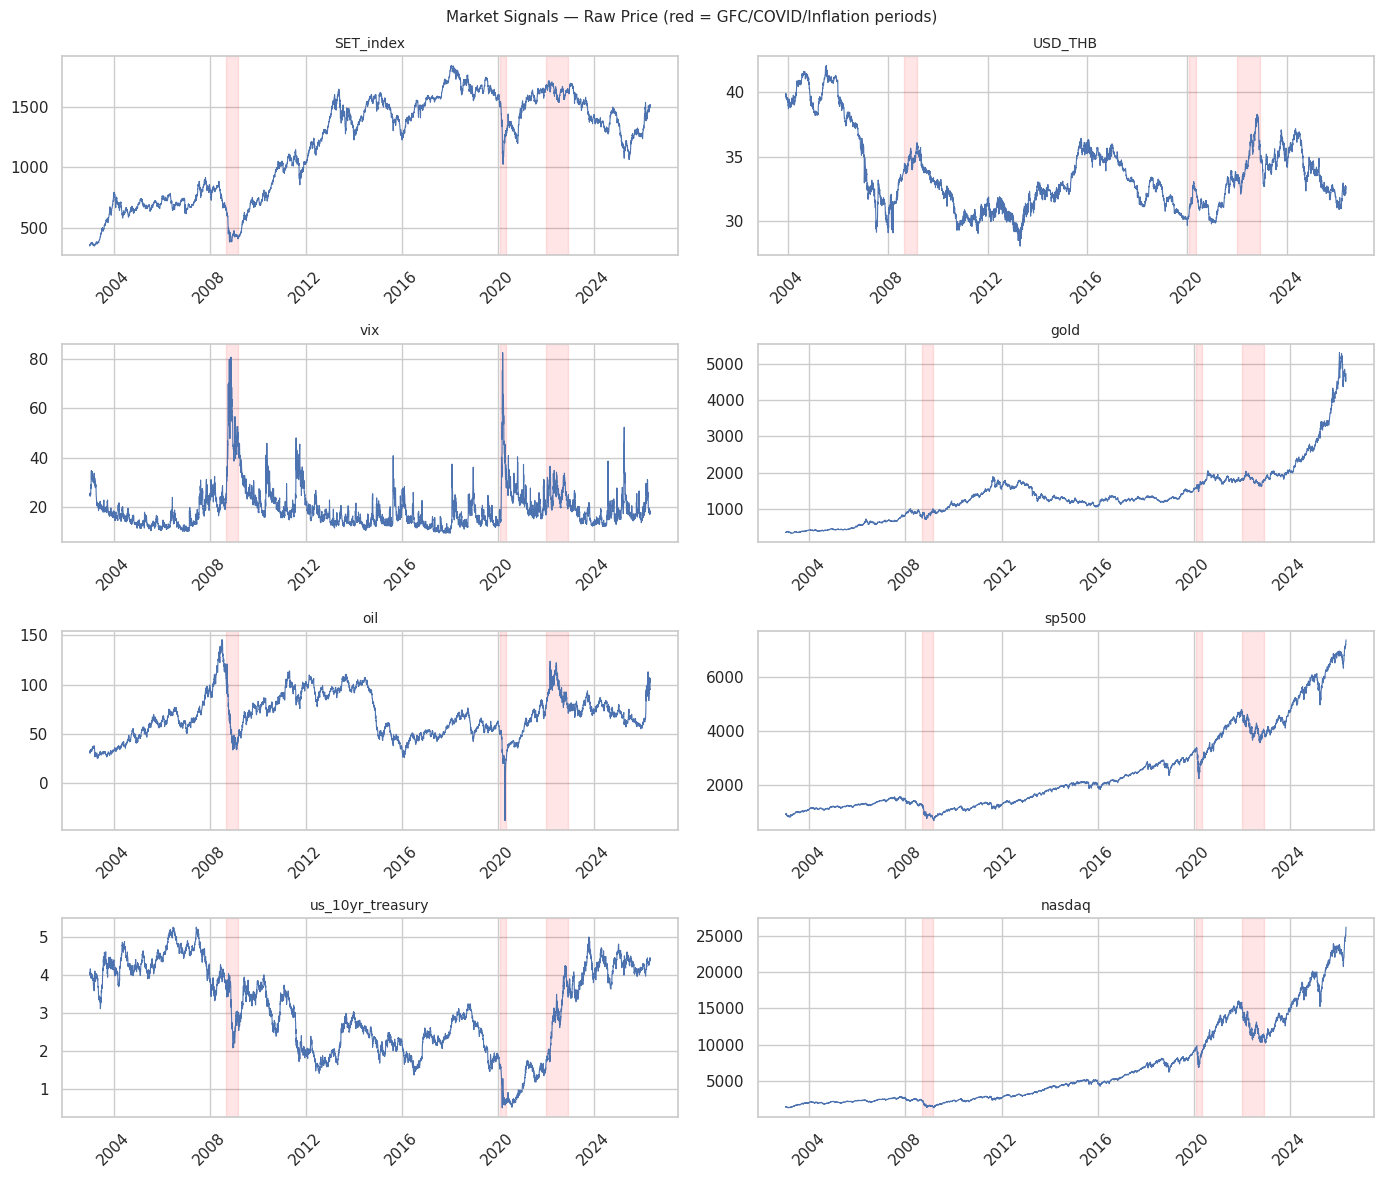

In [9]:
fig, axes = plt.subplots(4, 2, figsize=(14, 12))
axes = axes.flatten()
crisis = [('2008-09-01','2009-03-01','GFC'),('2020-02-01','2020-05-01','COVID'),('2022-01-01','2022-12-01','Inflation')]

for ax, col in zip(axes, MARKET_NAMES):
    s = market[col].dropna()
    ax.plot(s.index, s.values, lw=0.8)
    for st,en,_ in crisis:
        ax.axvspan(pd.Timestamp(st), pd.Timestamp(en), alpha=0.1, color='red')
    ax.set_title(col, fontsize=10)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator(4))
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('Market Signals — Raw Price (red = GFC/COVID/Inflation periods)', fontsize=11)
plt.tight_layout(); plt.show()

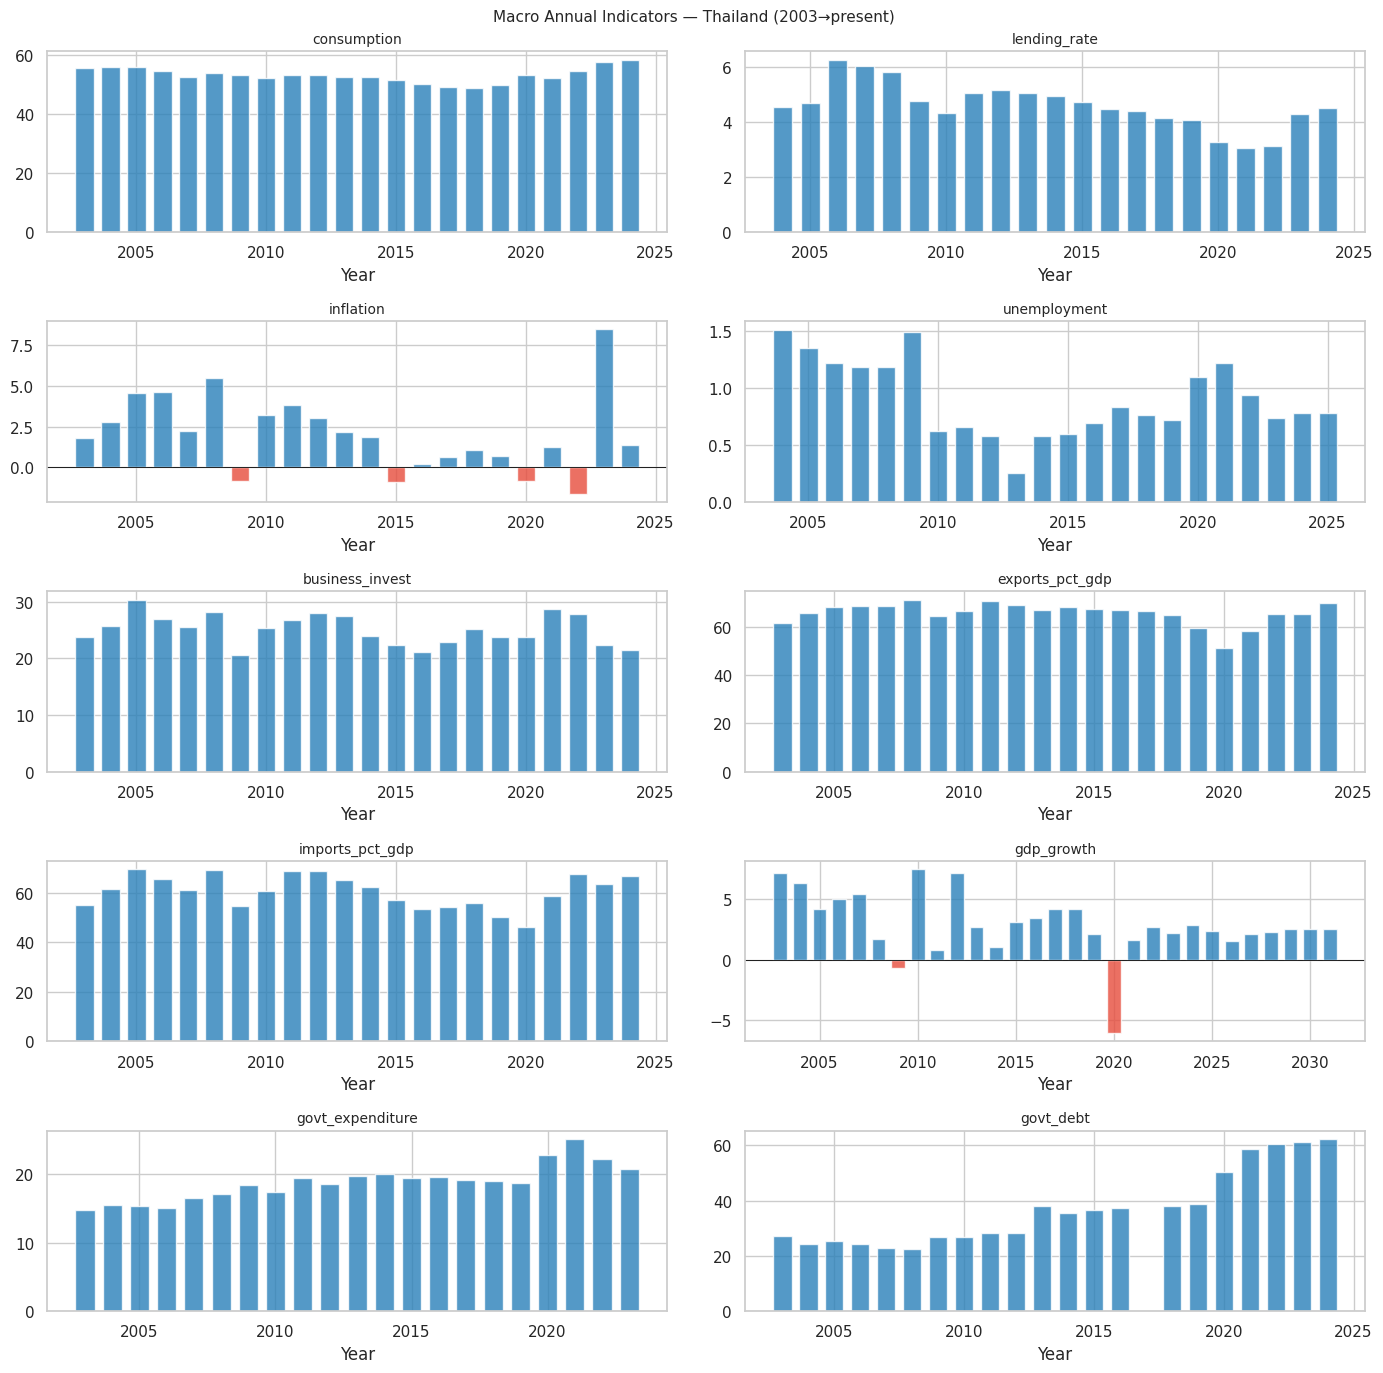

In [10]:
macro_2003 = macro[macro.index >= 2003]
fig, axes = plt.subplots(5, 2, figsize=(14, 14))
axes = axes.flatten()

for ax, col in zip(axes, macro_2003.columns):
    s = macro_2003[col].dropna()
    colors = ['#e74c3c' if v < 0 else '#2980b9' for v in s.values]
    ax.bar(s.index, s.values, color=colors, alpha=0.8, width=0.7)
    ax.axhline(0, color='black', lw=0.6)
    ax.set_title(col, fontsize=10); ax.set_xlabel('Year')

for ax in axes[len(macro_2003.columns):]: ax.set_visible(False)
plt.suptitle('Macro Annual Indicators — Thailand (2003→present)', fontsize=11)
plt.tight_layout(); plt.show()

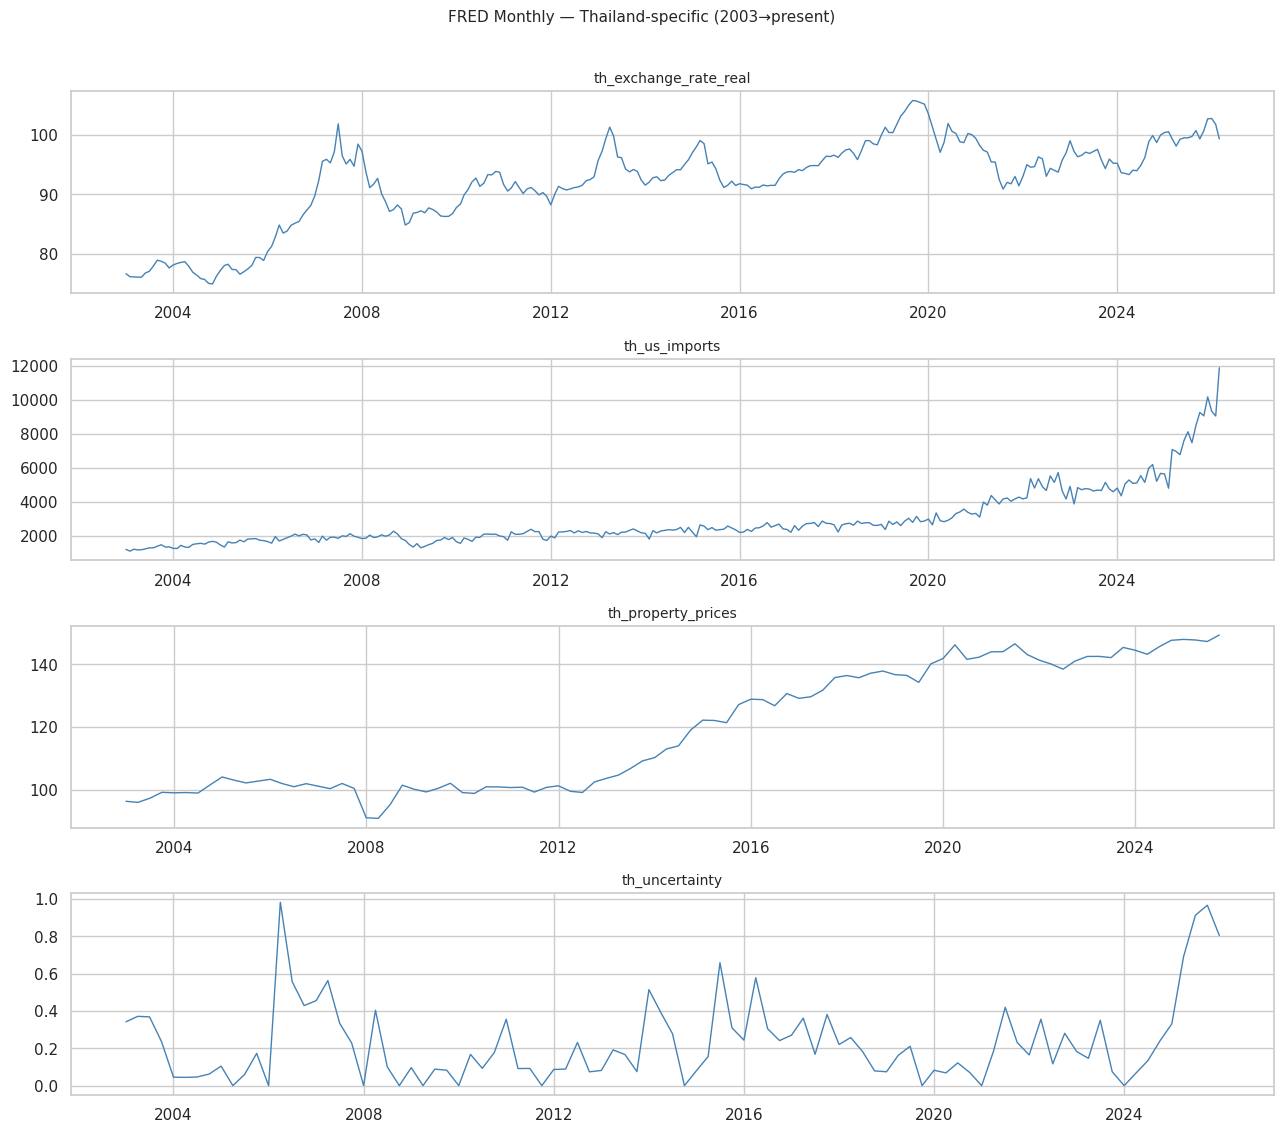

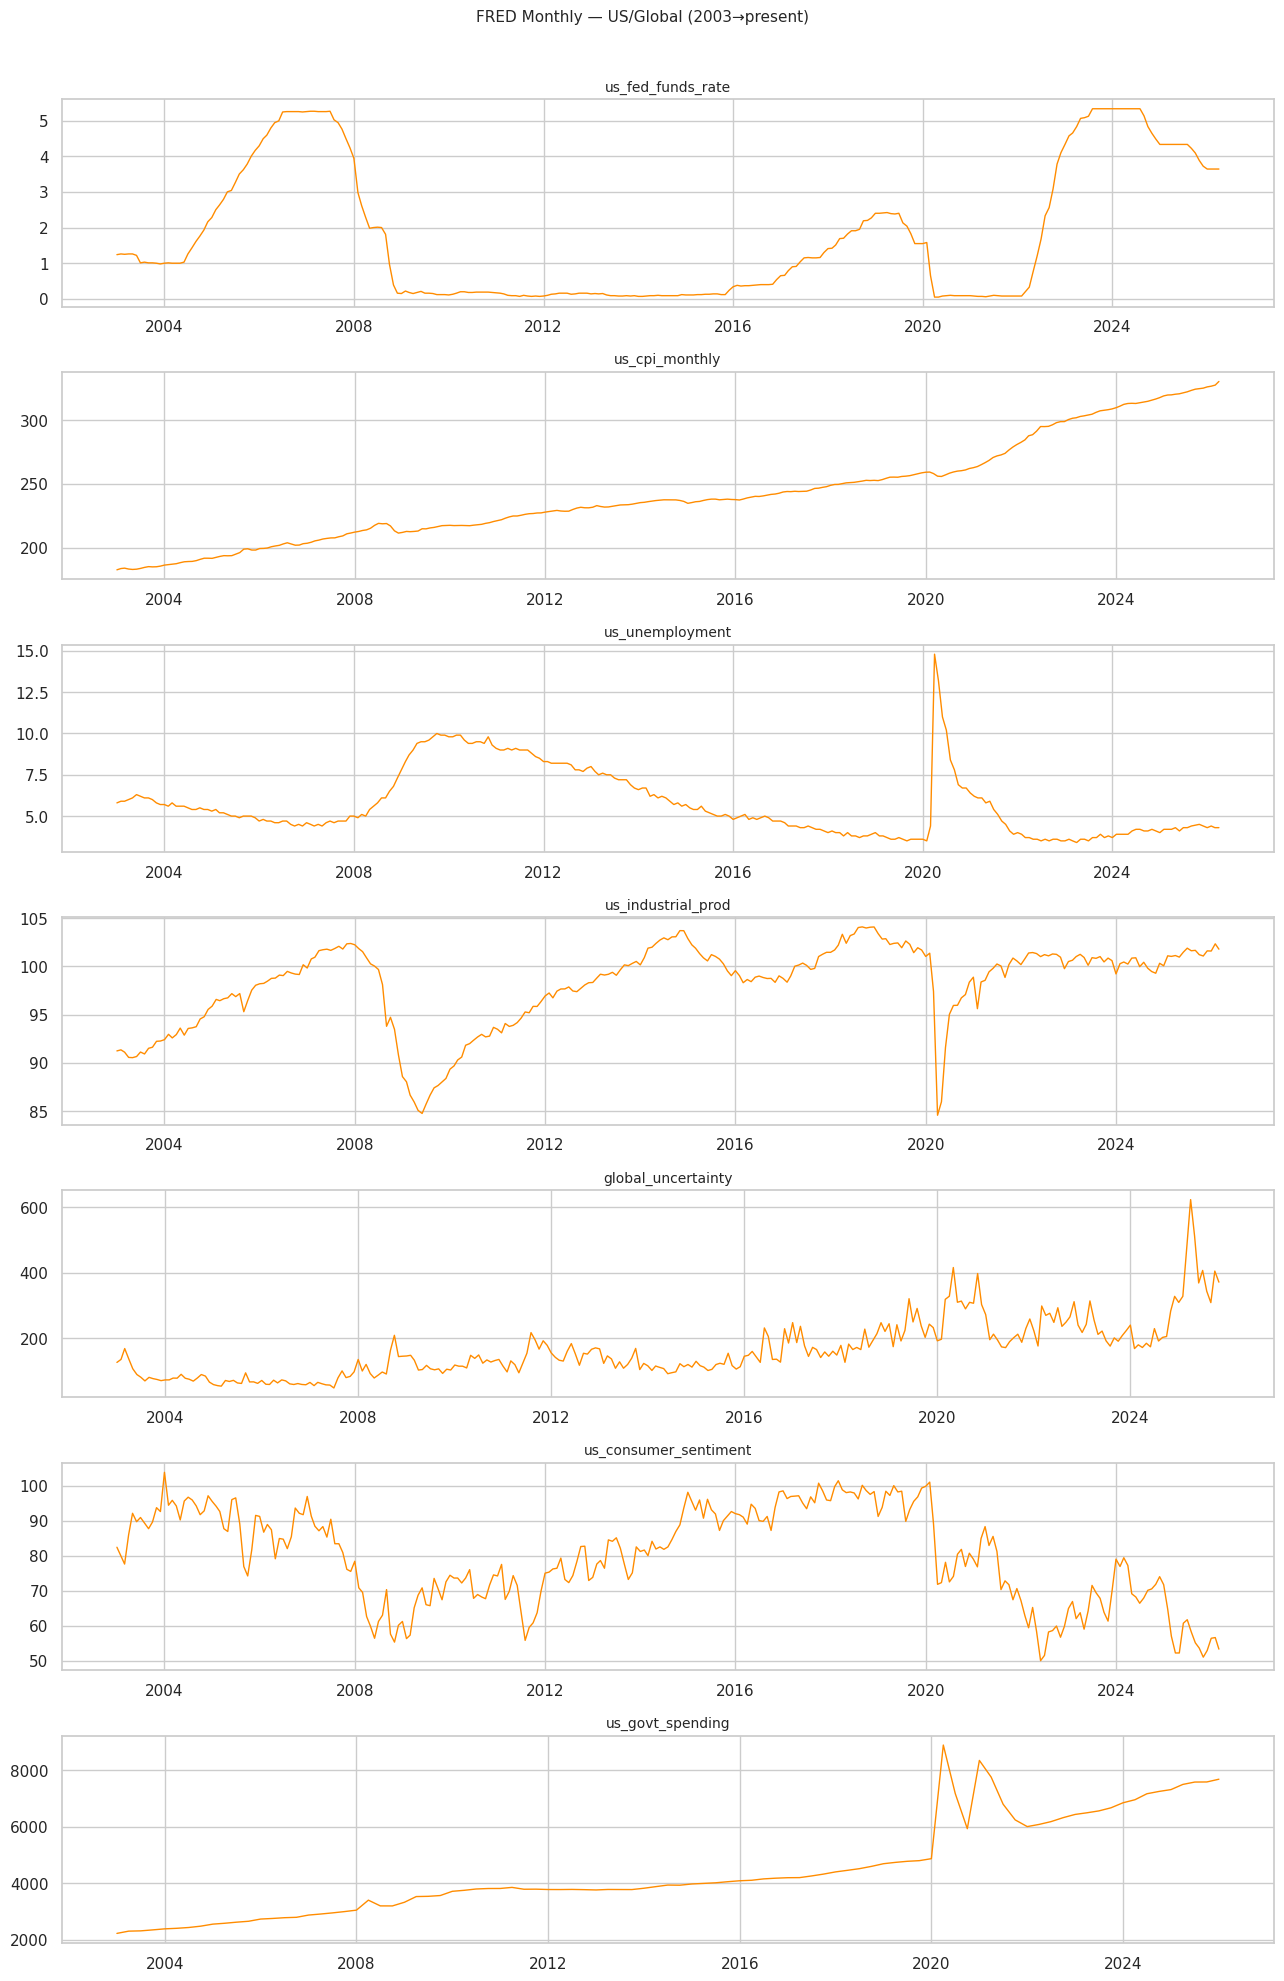

In [11]:
fred_2003 = fred[fred.index >= '2003-01-01']
th_cols = [c for c in fred_2003.columns if c.startswith('th_')]
us_cols = [c for c in fred_2003.columns if not c.startswith('th_')]

for group, cols, color, label in [(th_cols,'th_cols','steelblue','Thailand-specific'),
                                    (th_cols, us_cols,'darkorange','US/Global')]:
    use_cols = group if label == 'Thailand-specific' else us_cols
    fig, axes = plt.subplots(len(use_cols), 1, figsize=(13, 2.8*len(use_cols)))
    if len(use_cols)==1: axes=[axes]
    for ax, col in zip(axes, use_cols):
        s = fred_2003[col].dropna()
        ax.plot(s.index, s.values, lw=1, color=color)
        ax.set_title(col, fontsize=10)
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    plt.suptitle(f'FRED Monthly — {label} (2003→present)', fontsize=11, y=1.01)
    plt.tight_layout(); plt.show()

## 5. Distributions & Outlier Detection
Histogram ของ daily return + Z-score outlier count (|Z|>3 = สงสัยว่าเป็น anomaly)

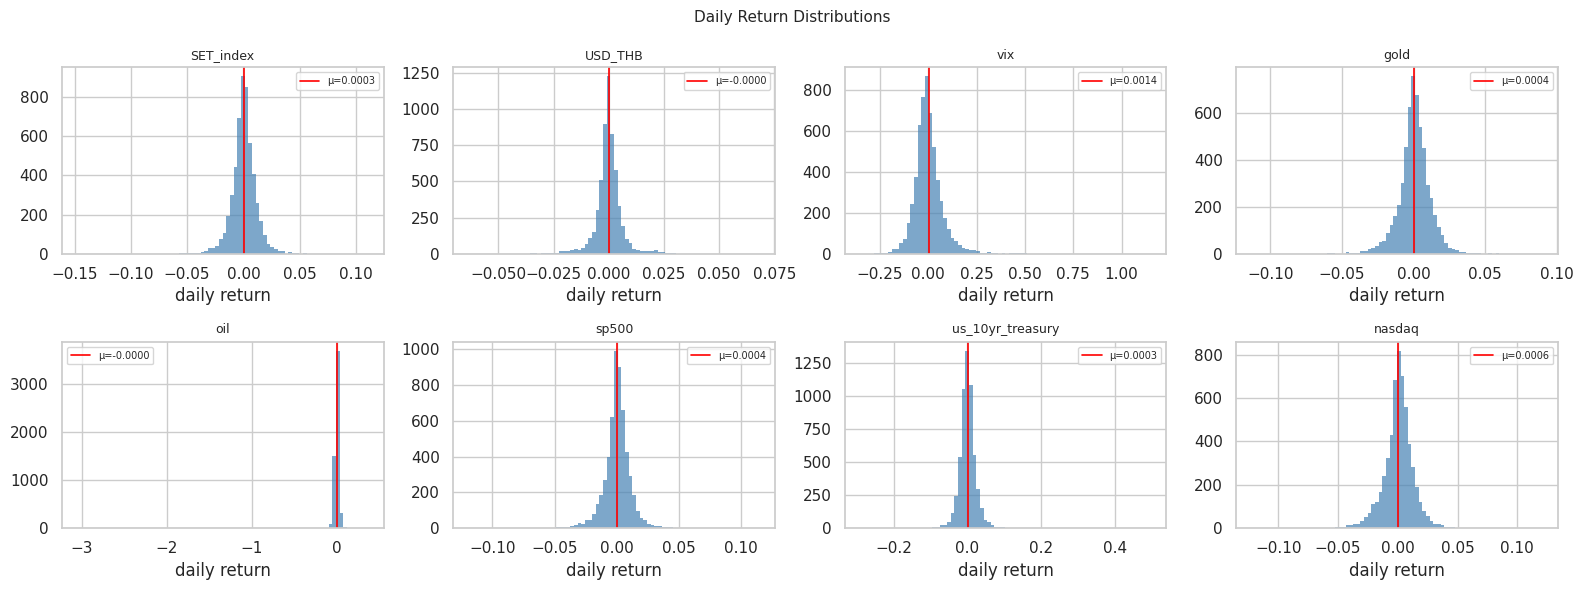

Market daily return outliers (|Z| > 3):
                  count |Z|>3  pct %  max |Z|
USD_THB                   160  2.630   10.710
sp500                      89  1.460   10.190
vix                        83  1.360   15.020
nasdaq                     81  1.330    9.140
gold                       76  1.250   10.020
SET_index                  64  1.050   12.870
us_10yr_treasury           64  1.050   19.900
oil                        15  0.250   59.730

FRED monthly return outliers (|Z| > 3):
                       count |Z|>3  pct %  max |Z|
us_fed_funds_rate                8  2.870    7.270
us_cpi_monthly                   6  2.150    6.330
global_uncertainty               5  1.790    4.050
us_industrial_prod               5  1.790   11.220
th_us_imports                    3  1.080    4.620
us_consumer_sentiment            2  0.720    3.360
th_exchange_rate_real            2  0.720    4.090
us_unemployment                  1  0.360   16.050
th_property_prices               0  0.000     

In [12]:
returns = market.pct_change().dropna(how='all')

fig, axes = plt.subplots(2, 4, figsize=(16, 6))
axes = axes.flatten()
for ax, col in zip(axes, returns.columns):
    r = returns[col].dropna()
    ax.hist(r, bins=80, color='steelblue', alpha=0.7, edgecolor='none')
    ax.axvline(r.mean(), color='red', lw=1.2, label=f'μ={r.mean():.4f}')
    ax.set_title(col, fontsize=9); ax.set_xlabel('daily return'); ax.legend(fontsize=7)
plt.suptitle('Daily Return Distributions', fontsize=11)
plt.tight_layout(); plt.show()

# Outlier summary table
z = (returns - returns.mean()) / returns.std()
out_mkt = pd.DataFrame({
    'count |Z|>3': (z.abs()>3).sum(),
    'pct %': ((z.abs()>3).mean()*100).round(2),
    'max |Z|': z.abs().max().round(2)
}).sort_values('count |Z|>3', ascending=False)

fred_ret = fred.pct_change().dropna(how='all')
fz = (fred_ret - fred_ret.mean()) / fred_ret.std()
out_fred = pd.DataFrame({
    'count |Z|>3': (fz.abs()>3).sum(),
    'pct %': ((fz.abs()>3).mean()*100).round(2),
    'max |Z|': fz.abs().max().round(2)
}).sort_values('count |Z|>3', ascending=False)

print('Market daily return outliers (|Z| > 3):')
print(out_mkt.to_string())
print('\nFRED monthly return outliers (|Z| > 3):')
print(out_fred.to_string())

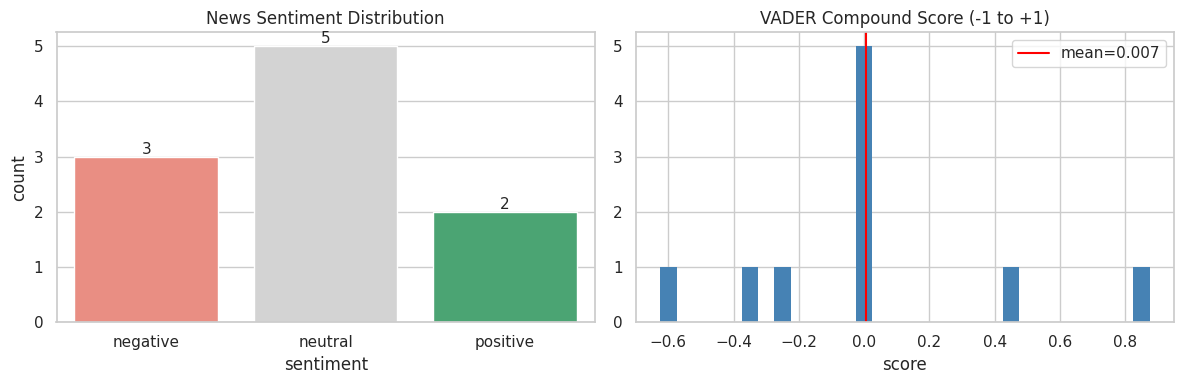

sentiment
neutral     5
negative    3
positive    2


In [13]:
# News sentiment overview
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sentiment_order = ['negative','neutral','positive']
palette = {'negative':'salmon','neutral':'lightgray','positive':'mediumseagreen'}
sns.countplot(data=news, x='sentiment', order=sentiment_order,
              hue='sentiment', palette=palette, legend=False, ax=axes[0])
axes[0].set_title('News Sentiment Distribution')
for p in axes[0].patches:
    axes[0].annotate(str(int(p.get_height())),
        (p.get_x()+p.get_width()/2, p.get_height()), ha='center', va='bottom', fontsize=11)

news['compound'].hist(bins=30, ax=axes[1], color='steelblue', edgecolor='none')
axes[1].axvline(news['compound'].mean(), color='red', lw=1.5,
                label=f'mean={news["compound"].mean():.3f}')
axes[1].set_title('VADER Compound Score (-1 to +1)')
axes[1].set_xlabel('score'); axes[1].legend()
plt.tight_layout(); plt.show()

print(news['sentiment'].value_counts().to_string())

## Key Findings — ปัญหาที่ต้องแก้ใน `02_data_cleaning.ipynb`

| # | ปัญหา | ผลกระทบถ้าไม่แก้ | วิธีแก้ |
|---|---|---|---|
| 1 | FRED + market บางตัวมีข้อมูลก่อนปี 2003 | training window ไม่ align → bias | Clip ≥ 2003-01-01 |
| 2 | Market daily มี gaps (holidays) | NaN กระจาย → correlation ผิดพลาด | Forward fill ≤ 5 วัน |
| 3 | FRED บางเดือน missing | ข้อมูลไม่ต่อเนื่อง | ffill ≤ 2 เดือน |
| 4 | Macro annual ขาดบางปี | gap ใน annual series | Linear interpolate |
| 5 | Outliers ใน daily return | distort correlation + model | Winsorize 1%/99% |
| 6 | 3 frequency ต่างกัน (daily/monthly/annual) | merge ไม่ได้ | Resample → monthly |

> **Note:** News sentiment เป็น current snapshot — ไม่มี historical data ใช้เป็น real-time signal เท่านั้น